### imports

In [1]:
import pandas as pd 
import numpy as np

### Download and load dataset

import os   
os.environ["HF_HOME"] = "F:\Programming\Transfomers\data"   
from datasets import load_dataset   
ds = load_dataset("openslr/librispeech_asr", "clean", split="train.100[:30000]")  

## or

https://www.openslr.org/12

In [2]:
import os
import pandas as pd

root = r"F:\Programming\Transfomers\data\dev-clean\LibriSpeech\dev-clean"

data = []

for speaker in os.listdir(root):
    speaker_path = os.path.join(root, speaker)

    if not os.path.isdir(speaker_path):
        continue

    for chapter in os.listdir(speaker_path):
        chapter_path = os.path.join(speaker_path, chapter)

        if not os.path.isdir(chapter_path):
            continue

        # find transcription file
        txt_files = [f for f in os.listdir(chapter_path) if f.endswith(".txt")]
        if not txt_files:
            continue

        txt_path = os.path.join(chapter_path, txt_files[0])

        # read transcripts
        transcripts = {}
        with open(txt_path, "r") as f:
            for line in f:
                key, text = line.strip().split(" ", 1)
                transcripts[key] = text

        # match audio with text
        for file in os.listdir(chapter_path):
            if file.endswith(".flac"):
                file_id = file.replace(".flac", "")
                audio_path = os.path.join(chapter_path, file)

                if file_id in transcripts:
                    data.append({
                        "audio": audio_path,
                        "text": transcripts[file_id]
                    })

# dataframe (HF-style feel)
df = pd.DataFrame(data)

print(df.head())
print("Total samples:", len(df))

                                               audio  \
0  F:\Programming\Transfomers\data\dev-clean\Libr...   
1  F:\Programming\Transfomers\data\dev-clean\Libr...   
2  F:\Programming\Transfomers\data\dev-clean\Libr...   
3  F:\Programming\Transfomers\data\dev-clean\Libr...   
4  F:\Programming\Transfomers\data\dev-clean\Libr...   

                                                text  
0  AS I APPROACHED THE CITY I HEARD BELLS RINGING...  
1  LOOKING ABOUT ME I SAW A GENTLEMAN IN A NEAT B...  
2  HE MUST HAVE REALIZED I WAS A STRANGER AND WIS...  
3  WE GAZED FOR A MOMENT SILENTLY INTO EACH OTHER...  
4  OF COURSE YOU ARE GOING THERE TOO I SAID TO MY...  
Total samples: 5567


In [3]:
df

,audio,text
0,F:\Programming\Transfomers\data\dev-clean\Libr...,AS I APPROACHED THE CITY I HEARD BELLS RINGING...
1,F:\Programming\Transfomers\data\dev-clean\Libr...,LOOKING ABOUT ME I SAW A GENTLEMAN IN A NEAT B...
2,F:\Programming\Transfomers\data\dev-clean\Libr...,HE MUST HAVE REALIZED I WAS A STRANGER AND WIS...
3,F:\Programming\Transfomers\data\dev-clean\Libr...,WE GAZED FOR A MOMENT SILENTLY INTO EACH OTHER...
4,F:\Programming\Transfomers\data\dev-clean\Libr...,OF COURSE YOU ARE GOING THERE TOO I SAID TO MY...
...,...,...
5562,F:\Programming\Transfomers\data\dev-clean\Libr...,ORGAN OF RUT NOT REASON IS THE LORD WHO FROM T...
5563,F:\Programming\Transfomers\data\dev-clean\Libr...,WELL TOO IF HE LIKE LOVE WOULD FILCH OUR HOARD...
5564,F:\Programming\Transfomers\data\dev-clean\Libr...,HEAVEN HELP THAT BODY WHICH A LITTLE MIND HOUS...
5565,F:\Programming\Transfomers\data\dev-clean\Libr...,DUE TO THEE THEIR PRAISE OF MAIDEN PURE OF TEE...


### Lowercase

In [4]:
df["text"] = df["text"].str.lower()

### Build vocab

In [5]:
special_tokens = ["<pad>", "<sos>", "<eos>"]
vocab = {tok: i for i, tok in enumerate(special_tokens)}

idx = len(vocab)

for text in df["text"]:
    for ch in text:
        if ch not in vocab:
            vocab[ch] = idx
            idx += 1

# reverse vocab (optional)
inv_vocab = {v: k for k, v in vocab.items()}

print("Vocab size:", len(vocab))

Vocab size: 31


In [6]:
vocab

{'<pad>': 0,
 '<sos>': 1,
 '<eos>': 2,
 'a': 3,
 's': 4,
 ' ': 5,
 'i': 6,
 'p': 7,
 'r': 8,
 'o': 9,
 'c': 10,
 'h': 11,
 'e': 12,
 'd': 13,
 't': 14,
 'y': 15,
 'b': 16,
 'l': 17,
 'n': 18,
 'g': 19,
 'f': 20,
 'u': 21,
 'w': 22,
 'm': 23,
 'k': 24,
 'x': 25,
 'v': 26,
 'z': 27,
 "'": 28,
 'q': 29,
 'j': 30}

### encode and decode functions

In [7]:
def encode(text):
    return [vocab["<sos>"]] + [vocab[ch] for ch in text] + [vocab["<eos>"]]

df["input_ids"] = df["text"].apply(encode)

In [8]:
def decode(tokens):
    text = ""
    for t in tokens:
        if t == vocab["<eos>"]:
            break
        if t in inv_vocab:
            ch = inv_vocab[t]
            if ch not in ["<sos>", "<pad>"]:
                text += ch
    return text

In [9]:
encode('i am nobody')

[1, 6, 5, 3, 23, 5, 18, 9, 16, 9, 13, 15, 2]

In [10]:
decode([1, 6, 5, 3, 23, 5, 18, 9, 16, 9, 13, 15, 2])

'i am nobody'

### creating lables

In [11]:
def shift_labels(seq):
    return seq[1:] + [vocab["<pad>"]]

df["labels"] = df["input_ids"].apply(shift_labels)

In [12]:
shift_labels([1, 6, 5, 3, 23, 5, 18, 9, 16, 9, 13, 15, 2])

[6, 5, 3, 23, 5, 18, 9, 16, 9, 13, 15, 2, 0]

### pading text seq

In [13]:
max_len = max(len(x) for x in df["input_ids"])

def pad(seq):
    return seq + [vocab["<pad>"]] * (max_len - len(seq))

df["input_ids"] = df["input_ids"].apply(pad)
df["labels"] = df["labels"].apply(pad)

In [14]:
max_len

518

## preprocess audio

#### **librosa.load(path, sr=16000)**
**Waveform**
(L,)

#### **librosa.feature.melspectrogram(...)**
**Framing → FFT → Power → Mel**   
(L,) → (T, K) → (T, F)   F = K/2 + 1 → (T, F) → (M, T)     
Output Shape    
(M, T)

#### **librosa.power_to_db(mel)**
**Log**    
(M, T)   
Output Shape   
(M, T)

#### **log_mel.T**
**Transpose**    
(M, T) → (T, M)    
Output Shape      
(T, M)

#### **np.pad(...)**
**Padding**        
(T, M) → (T_max, M)   
Output Shape        
(T_max, M)

In [15]:
import librosa
import numpy as np

def audio_to_mel(path):
    audio, sr = librosa.load(path, sr=16000)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=400,
        hop_length=160,
        n_mels=80
    )

    log_mel = librosa.power_to_db(mel)
    return log_mel.T   # [T, 80]

df["audio_features"] = df["audio"].apply(audio_to_mel)

In [16]:
df

,audio,text,input_ids,labels,audio_features
0,F:\Programming\Transfomers\data\dev-clean\Libr...,as i approached the city i heard bells ringing...,"[1, 3, 4, 5, 6, 5, 3, 7, 7, 8, 9, 3, 10, 11, 1...","[3, 4, 5, 6, 5, 3, 7, 7, 8, 9, 3, 10, 11, 12, ...","[[-69.46431, -69.46431, -69.46431, -69.46431, ..."
1,F:\Programming\Transfomers\data\dev-clean\Libr...,looking about me i saw a gentleman in a neat b...,"[1, 17, 9, 9, 24, 6, 18, 19, 5, 3, 16, 9, 21, ...","[17, 9, 9, 24, 6, 18, 19, 5, 3, 16, 9, 21, 14,...","[[-73.548035, -73.548035, -73.548035, -73.5480..."
2,F:\Programming\Transfomers\data\dev-clean\Libr...,he must have realized i was a stranger and wis...,"[1, 11, 12, 5, 23, 21, 4, 14, 5, 11, 3, 26, 12...","[11, 12, 5, 23, 21, 4, 14, 5, 11, 3, 26, 12, 5...","[[-70.74029, -70.74029, -70.74029, -70.74029, ..."
3,F:\Programming\Transfomers\data\dev-clean\Libr...,we gazed for a moment silently into each other...,"[1, 22, 12, 5, 19, 3, 27, 12, 13, 5, 20, 9, 8,...","[22, 12, 5, 19, 3, 27, 12, 13, 5, 20, 9, 8, 5,...","[[-71.93908, -71.93908, -71.93908, -71.93908, ..."
4,F:\Programming\Transfomers\data\dev-clean\Libr...,of course you are going there too i said to my...,"[1, 9, 20, 5, 10, 9, 21, 8, 4, 12, 5, 15, 9, 2...","[9, 20, 5, 10, 9, 21, 8, 4, 12, 5, 15, 9, 21, ...","[[-69.36441, -69.36441, -69.36441, -69.36441, ..."
...,...,...,...,...,...
5562,F:\Programming\Transfomers\data\dev-clean\Libr...,organ of rut not reason is the lord who from t...,"[1, 9, 8, 19, 3, 18, 5, 9, 20, 5, 8, 21, 14, 5...","[9, 8, 19, 3, 18, 5, 9, 20, 5, 8, 21, 14, 5, 1...","[[-44.75681, -47.756714, -52.66356, -58.38747,..."
5563,F:\Programming\Transfomers\data\dev-clean\Libr...,well too if he like love would filch our hoard...,"[1, 22, 12, 17, 17, 5, 14, 9, 9, 5, 6, 20, 5, ...","[22, 12, 17, 17, 5, 14, 9, 9, 5, 6, 20, 5, 11,...","[[-49.243584, -50.335888, -48.968803, -49.7754..."
5564,F:\Programming\Transfomers\data\dev-clean\Libr...,heaven help that body which a little mind hous...,"[1, 11, 12, 3, 26, 12, 18, 5, 11, 12, 17, 7, 5...","[11, 12, 3, 26, 12, 18, 5, 11, 12, 17, 7, 5, 1...","[[-50.034985, -51.711426, -51.800915, -52.0026..."
5565,F:\Programming\Transfomers\data\dev-clean\Libr...,due to thee their praise of maiden pure of tee...,"[1, 13, 21, 12, 5, 14, 9, 5, 14, 11, 12, 12, 5...","[13, 21, 12, 5, 14, 9, 5, 14, 11, 12, 12, 5, 1...","[[-47.449036, -49.46217, -51.58102, -54.435368..."


### pading audio seq

In [17]:
max_audio_len = max(x.shape[0] for x in df["audio_features"])

def pad_audio(x):
    pad_width = max_audio_len - x.shape[0]
    return np.pad(x, ((0, pad_width), (0, 0)))

df["audio_features"] = df["audio_features"].apply(pad_audio)

In [18]:
max_audio_len

3516

In [19]:
df

,audio,text,input_ids,labels,audio_features
0,F:\Programming\Transfomers\data\dev-clean\Libr...,as i approached the city i heard bells ringing...,"[1, 3, 4, 5, 6, 5, 3, 7, 7, 8, 9, 3, 10, 11, 1...","[3, 4, 5, 6, 5, 3, 7, 7, 8, 9, 3, 10, 11, 12, ...","[[-69.46431, -69.46431, -69.46431, -69.46431, ..."
1,F:\Programming\Transfomers\data\dev-clean\Libr...,looking about me i saw a gentleman in a neat b...,"[1, 17, 9, 9, 24, 6, 18, 19, 5, 3, 16, 9, 21, ...","[17, 9, 9, 24, 6, 18, 19, 5, 3, 16, 9, 21, 14,...","[[-73.548035, -73.548035, -73.548035, -73.5480..."
2,F:\Programming\Transfomers\data\dev-clean\Libr...,he must have realized i was a stranger and wis...,"[1, 11, 12, 5, 23, 21, 4, 14, 5, 11, 3, 26, 12...","[11, 12, 5, 23, 21, 4, 14, 5, 11, 3, 26, 12, 5...","[[-70.74029, -70.74029, -70.74029, -70.74029, ..."
3,F:\Programming\Transfomers\data\dev-clean\Libr...,we gazed for a moment silently into each other...,"[1, 22, 12, 5, 19, 3, 27, 12, 13, 5, 20, 9, 8,...","[22, 12, 5, 19, 3, 27, 12, 13, 5, 20, 9, 8, 5,...","[[-71.93908, -71.93908, -71.93908, -71.93908, ..."
4,F:\Programming\Transfomers\data\dev-clean\Libr...,of course you are going there too i said to my...,"[1, 9, 20, 5, 10, 9, 21, 8, 4, 12, 5, 15, 9, 2...","[9, 20, 5, 10, 9, 21, 8, 4, 12, 5, 15, 9, 21, ...","[[-69.36441, -69.36441, -69.36441, -69.36441, ..."
...,...,...,...,...,...
5562,F:\Programming\Transfomers\data\dev-clean\Libr...,organ of rut not reason is the lord who from t...,"[1, 9, 8, 19, 3, 18, 5, 9, 20, 5, 8, 21, 14, 5...","[9, 8, 19, 3, 18, 5, 9, 20, 5, 8, 21, 14, 5, 1...","[[-44.75681, -47.756714, -52.66356, -58.38747,..."
5563,F:\Programming\Transfomers\data\dev-clean\Libr...,well too if he like love would filch our hoard...,"[1, 22, 12, 17, 17, 5, 14, 9, 9, 5, 6, 20, 5, ...","[22, 12, 17, 17, 5, 14, 9, 9, 5, 6, 20, 5, 11,...","[[-49.243584, -50.335888, -48.968803, -49.7754..."
5564,F:\Programming\Transfomers\data\dev-clean\Libr...,heaven help that body which a little mind hous...,"[1, 11, 12, 3, 26, 12, 18, 5, 11, 12, 17, 7, 5...","[11, 12, 3, 26, 12, 18, 5, 11, 12, 17, 7, 5, 1...","[[-50.034985, -51.711426, -51.800915, -52.0026..."
5565,F:\Programming\Transfomers\data\dev-clean\Libr...,due to thee their praise of maiden pure of tee...,"[1, 13, 21, 12, 5, 14, 9, 5, 14, 11, 12, 12, 5...","[13, 21, 12, 5, 14, 9, 5, 14, 11, 12, 12, 5, 1...","[[-47.449036, -49.46217, -51.58102, -54.435368..."


### dataset

In [20]:
dataset = []

for i in range(len(df)):
    dataset.append({
        "audio_features": df.iloc[i]["audio_features"],   # [T, 80]
        "decoder_input_ids": df.iloc[i]["input_ids"],     # [L]
        "labels": df.iloc[i]["labels"]                    # [L]
    })

print(dataset[0].keys())

dict_keys(['audio_features', 'decoder_input_ids', 'labels'])


In [85]:
#dataset[0]

In [22]:
import torch

In [23]:
print(torch.tensor(dataset[0]['audio_features']))

tensor([[-69.4643, -69.4643, -69.4643,  ..., -69.4643, -69.4643, -69.4643],
        [-69.4643, -69.4643, -69.4643,  ..., -69.4643, -69.4643, -69.4643],
        [-69.4643, -69.4643, -69.4643,  ..., -69.4643, -69.4643, -69.4643],
        ...,
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
        [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000]])


In [24]:
torch.tensor(dataset[0]['audio_features']).shape

torch.Size([3516, 80])

In [25]:
torch.tensor(dataset[0]['decoder_input_ids']).shape

torch.Size([518])

In [26]:
torch.tensor(dataset[0]['labels']).shape

torch.Size([518])

### data visualization

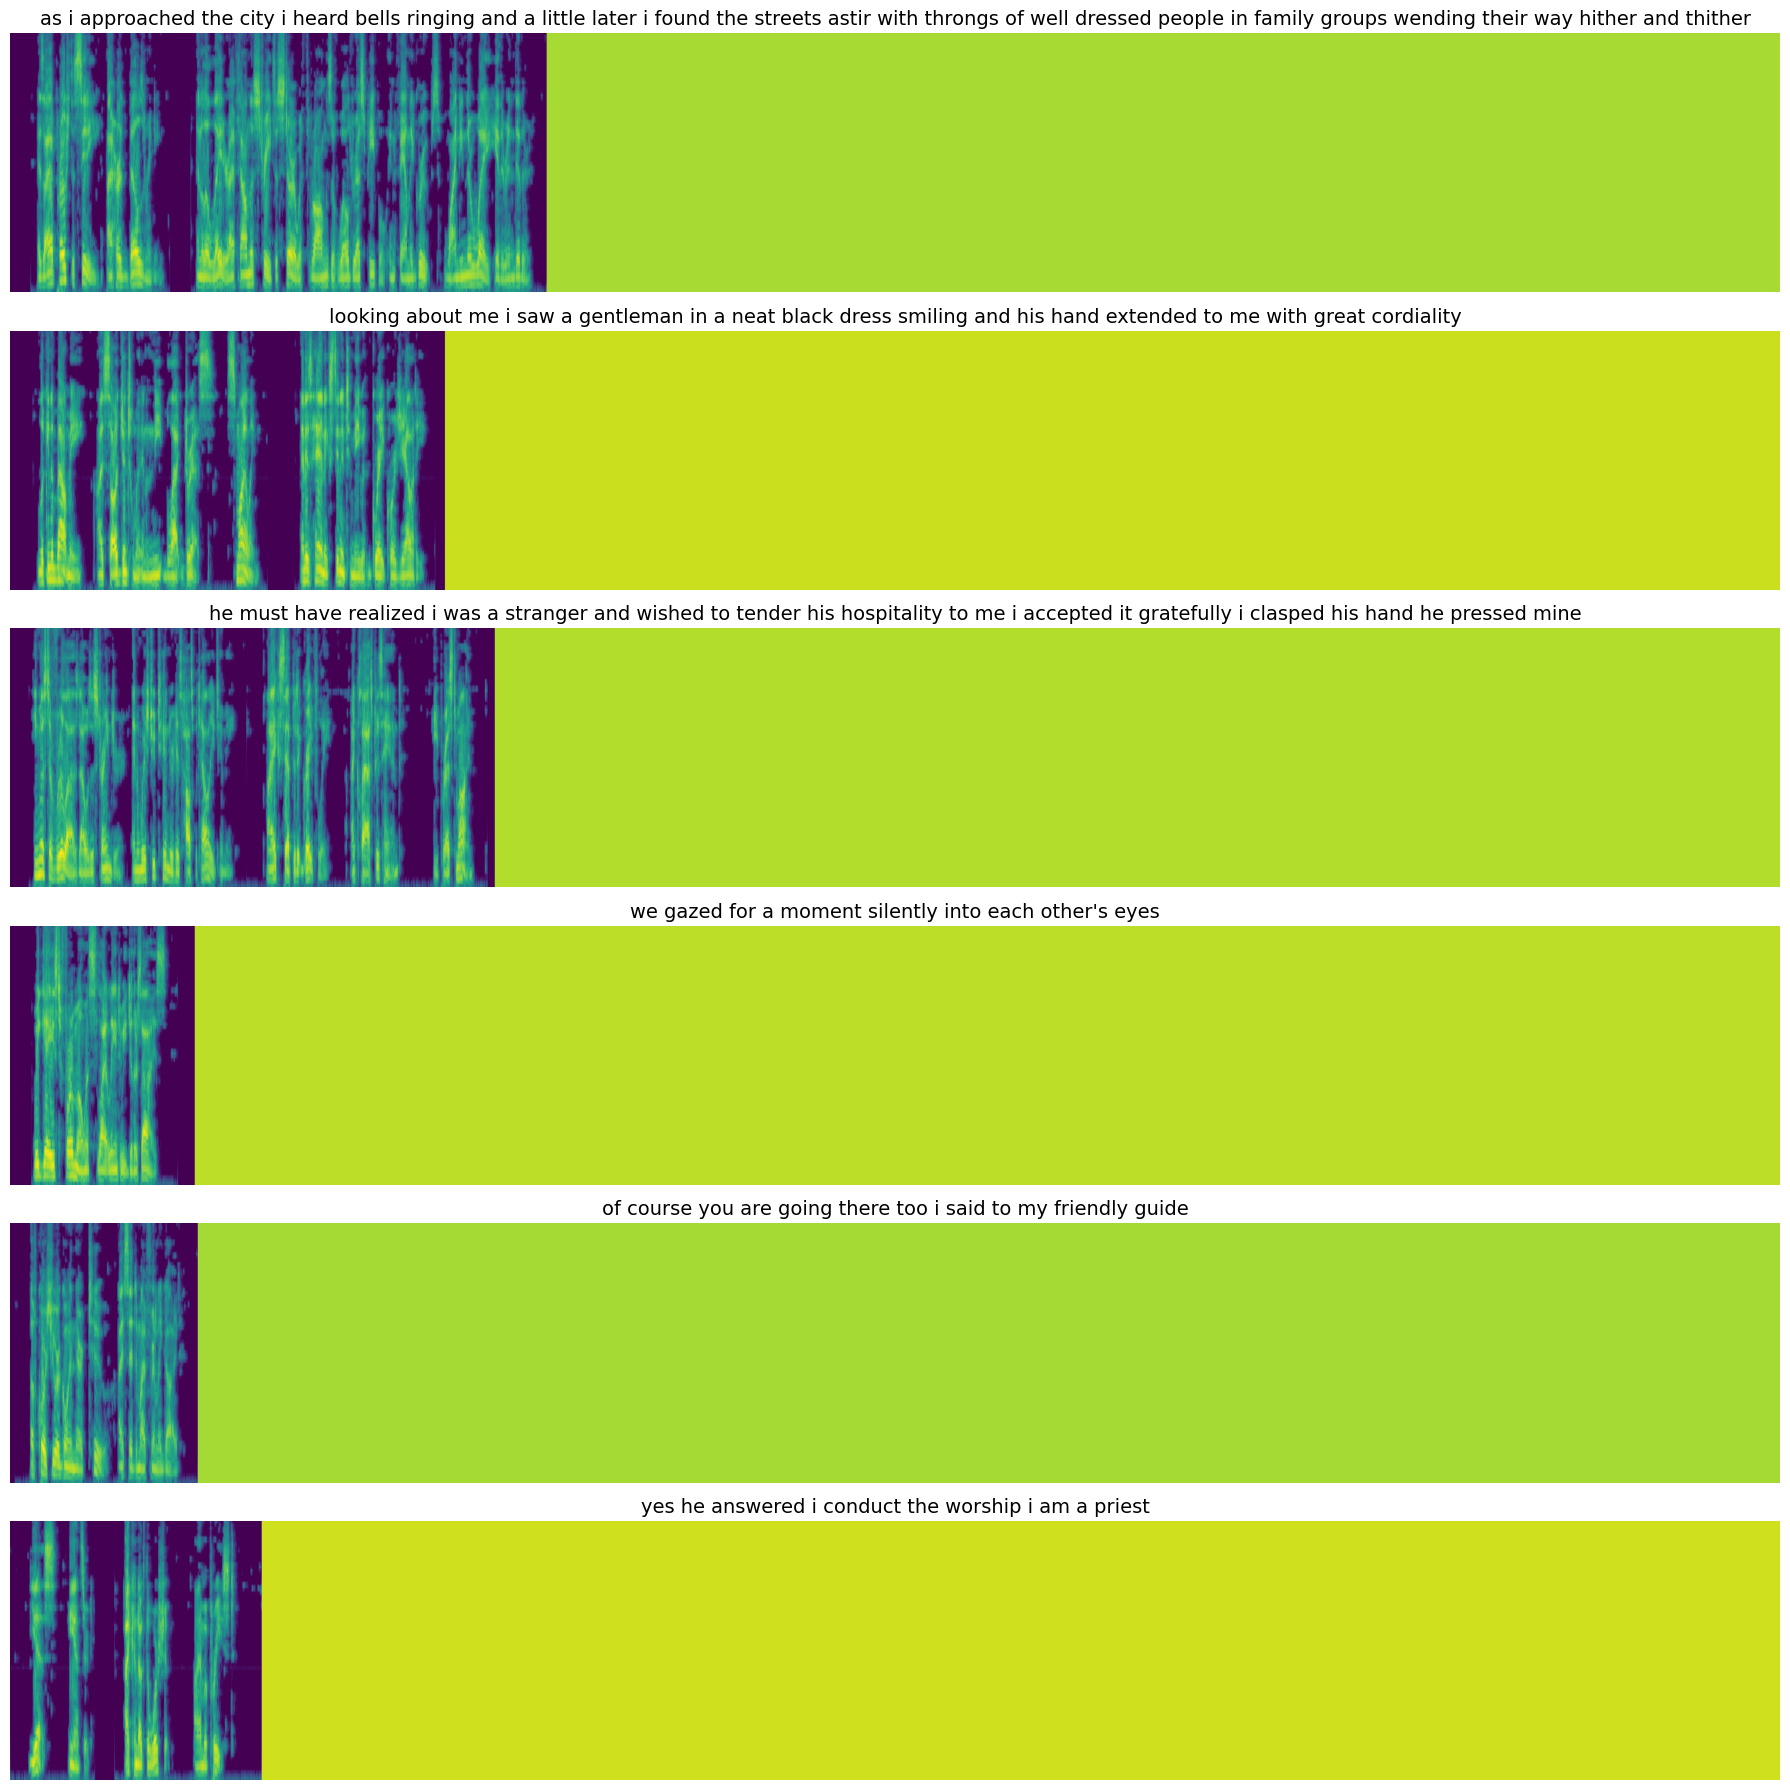

In [27]:
import matplotlib.pyplot as plt

num_samples = 6

plt.figure(figsize=(18, 3 * num_samples))

for i in range(num_samples):
    sample = dataset[i]["audio_features"]

    plt.subplot(num_samples, 1, i + 1)
    plt.imshow(sample.T, aspect='auto', origin='lower')
    plt.title(decode(dataset[i]['decoder_input_ids']), fontsize=14) 
    plt.axis("off")

plt.tight_layout()
plt.show()

### PyTorch Dataset Class

In [28]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [29]:
class ASRDataset(Dataset):
    def __init__(self, dataset_list):
        self.data = dataset_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        audio = torch.tensor(sample["audio_features"], dtype=torch.float32)
        decoder_input = torch.tensor(sample["decoder_input_ids"], dtype=torch.long)
        labels = torch.tensor(sample["labels"], dtype=torch.long)

        return {
            "audio_features": audio,          # [T, 80]
            "decoder_input_ids": decoder_input,  # [L]
            "labels": labels                     # [L]
        }

### Create Dataset + Check

In [30]:
# create dataset
asr_dataset = ASRDataset(dataset)

# check length
print("Dataset size:", len(asr_dataset))

# get one sample
sample = asr_dataset[0]

print("Keys:", sample.keys())
print("Audio shape:", sample["audio_features"].shape)
print("Decoder input shape:", sample["decoder_input_ids"].shape)
print("Labels shape:", sample["labels"].shape)

Dataset size: 5567
Keys: dict_keys(['audio_features', 'decoder_input_ids', 'labels'])
Audio shape: torch.Size([3516, 80])
Decoder input shape: torch.Size([518])
Labels shape: torch.Size([518])


In [83]:
#sample

In [32]:
print(decode(sample["labels"].numpy()))

as i approached the city i heard bells ringing and a little later i found the streets astir with throngs of well dressed people in family groups wending their way hither and thither


### DataLoader

In [33]:
# create dataloader
train_loader = DataLoader(
    asr_dataset,
    batch_size=5,     # adjust based on GPU
    shuffle=True,
)

In [34]:
batch = next(iter(train_loader))

print("Audio batch:", batch["audio_features"].shape)
print("Decoder input batch:", batch["decoder_input_ids"].shape)
print("Labels batch:", batch["labels"].shape)

Audio batch: torch.Size([5, 3516, 80])
Decoder input batch: torch.Size([5, 518])
Labels batch: torch.Size([5, 518])


# Transfomer Architecture

Audio:
→ PatchEmbed → Pos → confomer (Encoder) → audio_tokens (B, 64, 768)

Text:
→ Embedding → Pos → text_tokens (B, 127, 768)

Decoder:
→ Masked Self-Attn (text)
→ Cross-Attn (text ↔ audio)
→ FF

Output:
→ Linear → vocab

Patch embedding = non-overlapping, one-shot   
Subsampling = progressive, overlapping    
but Same implementation   

In [35]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import math

### Patch Embedding Module

In [36]:
class PatchEmbedding(nn.Module):
    def __init__(self, d_model=512):
        super().__init__()

        self.proj = nn.Sequential( # Input: (B, 1, 3516, 80)

            nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1),   # → (B, 64, 1758, 40)
            nn.GELU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # → (B, 128, 879, 20)
            nn.GELU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # → (B, 256, 440, 10)
            nn.GELU(),

            nn.Conv2d(256, d_model, kernel_size=3, stride=2, padding=1), # → (B, 512, 220, 5)
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """
        x: (B, 3516, 80)
        """

        x = x.unsqueeze(1)   # → (B, 1, 3516, 80)

        x = self.proj(x)     # → (B, 512, 220, 5)

        B, C, H, W = x.shape

        x = x.flatten(2)     # → (B, 512, 1100)

        x = x.transpose(1, 2)    # → (B, 1100, 512)

        x = self.norm(x)

        return x

In [37]:
x = torch.randn(2, 3516, 80)

patch_embed = PatchEmbedding()

out = patch_embed(x)

print("Input shape :", x.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([2, 3516, 80])
Output shape: torch.Size([2, 1100, 512])


### AudioPositionalEmbedding

In [38]:
class AudioPositionalEmbedding(nn.Module):
    def __init__(self, max_len=1200, d_model=512, dropout=0.1):
        super().__init__()

        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, 512)
        """

        T = x.size(1)

        x = x + self.pos_embed[:, :T, :]
        x = self.dropout(x)

        return x

In [39]:
x = torch.randn(2, 1100, 512)

pos = AudioPositionalEmbedding()

out = pos(x)

print(out.shape)

torch.Size([2, 1100, 512])


In [40]:
pos_embed = nn.Linear(5, 6)

### TextEmbedding + PositionalEmbedding

In [41]:
class TextPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, embdim, max_len=512, dropout=0.1):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embdim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, embdim)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # (1, T, D)

        self.scale = math.sqrt(embdim)

    def forward(self, x):
        """
        x: (B, T)
        """

        B, T = x.size()

        emb = self.embedding(x) * self.scale      # (B, T, D)
        emb = emb + self.pe[:, :T, :]             # (B, T, D)
        emb = self.dropout(emb)

        return emb

In [42]:
x = torch.randint(0, 31, (2, 10))

model = TextPositionalEmbedding(
    vocab_size=31,
    embdim=512,
    max_len=512
)

out = model(x)

print("Input shape :", x.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([2, 10])
Output shape: torch.Size([2, 10, 512])


In [43]:
import matplotlib.pyplot as plt

In [44]:
def plot_pos(max_len = 300 ,embdim = 60,cmap='Spectral'):

    # build PE from formula
    pe = torch.zeros(max_len, embdim)
    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    
    # plot
    plt.figure(figsize=(18, 8))
    plt.imshow(pe.T, aspect="auto", cmap=cmap)
    plt.colorbar(label="PE value")
    plt.xlabel("Position")
    plt.ylabel("Embedding dimension")
    plt.title("Sinusoidal Positional Encoding ")
    plt.show()


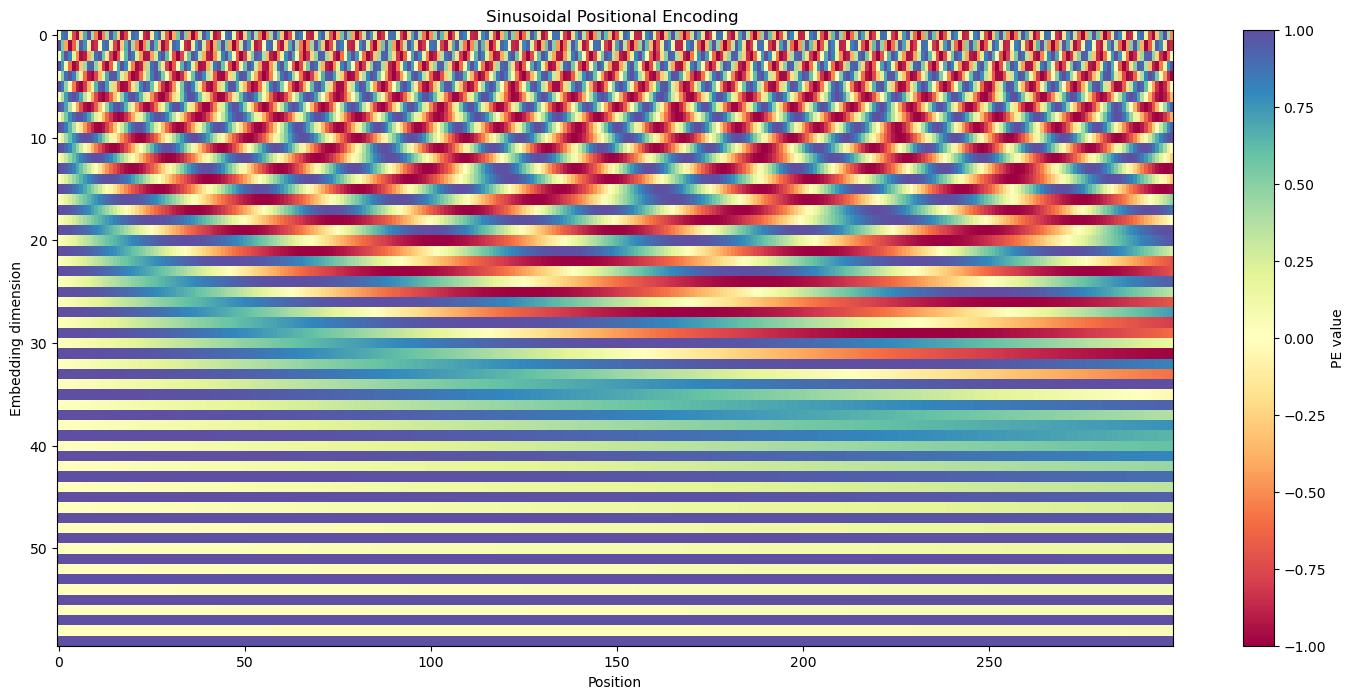

In [45]:
plot_pos()

## Conformer Encoder Architecture

### ConformerConvModule

In [46]:
class ConformerConvModule(nn.Module):
    def __init__(self, d_model, expansion_factor=2, kernel_size=31, dropout=0.1):
        super().__init__()

        inner_dim = d_model * expansion_factor

        self.layer_norm = nn.LayerNorm(d_model)

        self.pointwise_conv1 = nn.Conv1d(d_model, inner_dim * 2, kernel_size=1)
        self.glu = nn.GLU(dim=1)

        self.depthwise_conv = nn.Conv1d(
            inner_dim,
            inner_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=inner_dim
        )

        self.batch_norm = nn.BatchNorm1d(inner_dim)
        self.slu = nn.SiLU()

        self.pointwise_conv2 = nn.Conv1d(inner_dim, d_model, kernel_size=1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        x = self.layer_norm(x)

        x = x.transpose(1, 2)   # → (B, D, T)

        x = self.pointwise_conv1(x)   # → (B, 2*inner, T)
        x = self.glu(x)               # → (B, inner, T)

        x = self.depthwise_conv(x)    # → (B, inner, T)
        x = self.batch_norm(x)
        x = self.slu(x)

        x = self.pointwise_conv2(x)   # → (B, D, T)

        x = x.transpose(1, 2)         # → (B, T, D)

        return self.dropout(x)

### Multi-head-attention

In [47]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        B, T, D = x.shape

        qkv = self.qkv(x)  # (B, T, 3D)
        qkv = qkv.view(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### Feed-Forward Network

In [48]:
class FeedForwardModule(nn.Module):
    def __init__(self, d_model, expansion_factor=4, dropout=0.1):
        super().__init__()

        inner_dim = d_model * expansion_factor

        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, inner_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(inner_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

### ConformerBlock

In [49]:
class ConformerBlock(nn.Module):
    def __init__(self, d_model=512, num_heads=8, ff_expansion=4, conv_expansion=2, dropout=0.1):
        super().__init__()

        self.ff1 = FeedForwardModule(d_model, ff_expansion, dropout)
        self.mha = MultiHeadAttention(d_model, num_heads, dropout)
        self.conv = ConformerConvModule(d_model, conv_expansion, dropout=dropout)
        self.ff2 = FeedForwardModule(d_model, ff_expansion, dropout)

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        # Macaron FFN (half step)
        x = x + 0.5 * self.ff1(x)

        # MHSA
        x = x + self.mha(x)

        # Conv module
        x = x + self.conv(x)

        # Second FFN
        x = x + 0.5 * self.ff2(x)

        # Final norm
        x = self.norm(x)

        return x

### Conformer

In [50]:
class ConformerEncoder(nn.Module):
    def __init__(self, num_layers=6, d_model=512, num_heads=8):
        super().__init__()

        self.layers = nn.ModuleList([
            ConformerBlock(d_model=d_model, num_heads=num_heads)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        """
        x: (B, T, D)
        """

        for layer in self.layers:
            x = layer(x)

        return x

In [51]:
x = torch.randn(2, 3516, 80)

# modules
patch = PatchEmbedding(d_model=512)
pos = AudioPositionalEmbedding(max_len=1100, d_model=512)
encoder = ConformerEncoder(num_layers=2, d_model=512, num_heads=8)

# forward
out = patch(x)      # → (B, ~1100, 512)
out = pos(out)      # → (B, ~1100, 512)
out = encoder(out)  # → (B, ~1100, 512)

print("Input shape :", x.shape)
print("After patch :", out.shape)

Input shape : torch.Size([2, 3516, 80])
After patch : torch.Size([2, 1100, 512])


## DECODER Architecture

### MaskedMultiHeadAttention

In [52]:
class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, embdim, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # → (B, heads, T, T)

        # CAUSAL MASK
        mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        mask = mask.unsqueeze(0).unsqueeze(0)  # → (1,1,T,T)

        scores = scores.masked_fill(~mask, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        out = torch.matmul(weights, V)
        # → (B, heads, T, head_dim)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### CrossAttention

In [53]:
class CrossAttention(nn.Module):
    def __init__(self, embdim, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, context):
        """
        query:   (B, T, D) → text
        context: (B, N, D) → audio
        """

        B, T, D = query.shape
        N = context.shape[1]

        Q = self.Wq(query)
        K = self.Wk(context)
        V = self.Wv(context)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # → (B, heads, T, N)

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        out = torch.matmul(weights, V)
        # → (B, heads, T, head_dim)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### FeedForward

In [54]:
class FeedForward(nn.Module):
    def __init__(self, embdim, hidden_dim, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embdim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embdim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.net(x)

### DecoderBlock

In [55]:
class DecoderBlock(nn.Module):
    def __init__(self, embdim, num_heads, ff_hidden_dim, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embdim)
        self.norm2 = nn.LayerNorm(embdim)
        self.norm3 = nn.LayerNorm(embdim)

        self.self_attn = MaskedMultiHeadAttention(embdim, num_heads, dropout)
        self.cross_attn = CrossAttention(embdim, num_heads, dropout)
        self.ff = FeedForward(embdim, ff_hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, text_tokens, audio_tokens):
        """
        text_tokens:  (B, T, D)
        audio_tokens: (B, N, D)
        """

        # 1. Masked Self Attention
        x = text_tokens + self.dropout(
            self.self_attn(self.norm1(text_tokens))
        )

        # 2. Cross Attention (text ↔ audio)
        x = x + self.dropout(
            self.cross_attn(self.norm2(x), audio_tokens)
        )

        # 3. Feed Forward
        x = x + self.dropout(
            self.ff(self.norm3(x))
        )

        return x

### Decoder

In [56]:
class Decoder(nn.Module):
    def __init__(self, depth, embdim, num_heads, ff_hidden_dim):
        super().__init__()

        self.layers = nn.ModuleList([
            DecoderBlock(embdim, num_heads, ff_hidden_dim)
            for _ in range(depth)
        ])

    def forward(self, text_tokens, audio_tokens):
        """
        text_tokens:  (B, T, D)
        audio_tokens: (B, N, D)
        """

        for layer in self.layers:
            text_tokens = layer(text_tokens, audio_tokens)

        return text_tokens

In [57]:
# Dummy inputs
text = torch.randn(2, 518, 512)     # decoder input
audio = torch.randn(2, 1100, 512)   # encoder output

decoder = Decoder(
    depth=2,
    embdim=512,
    num_heads=8,
    ff_hidden_dim=2048
)

out = decoder(text, audio)

print("Text input shape :", text.shape)
print("Audio input shape:", audio.shape)
print("Output shape     :", out.shape)

Text input shape : torch.Size([2, 518, 512])
Audio input shape: torch.Size([2, 1100, 512])
Output shape     : torch.Size([2, 518, 512])


## Vocab Head

In [58]:
class VocabHead(nn.Module):
    def __init__(self, embdim, vocab_size):
        super().__init__()
        self.proj = nn.Linear(embdim, vocab_size)

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.proj(x)   # (B, T, vocab_size)

In [59]:
# Test parameters
B, T, D = 2, 518, 512
vocab_size = 31

# Random decoder output
decoder_out = torch.randn(B, T, D)

# Vocab head
vocab_head = VocabHead(embdim=D, vocab_size=vocab_size)

# Forward pass
logits = vocab_head(decoder_out)

print("Input shape :", decoder_out.shape)
print("Output shape:", logits.shape)

Input shape : torch.Size([2, 518, 512])
Output shape: torch.Size([2, 518, 31])


# TRANSFORMER MODEL

In [60]:
class ASRTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=512,
        encoder_layers=6,
        decoder_layers=6,
        num_heads=8,
        ff_expansion=4,
        conv_expansion=2,
        ff_hidden_dim=2048,
        max_audio_len=1200,
        max_text_len=518,
        dropout=0.1
    ):
        super().__init__()

        # Audio patch embedding + positional embedding
        self.patch_embed = PatchEmbedding(d_model=d_model)
        self.audio_pos = AudioPositionalEmbedding(max_len=max_audio_len, d_model=d_model, dropout=dropout)

        # Conformer encoder
        self.encoder = ConformerEncoder(num_layers=encoder_layers, d_model=d_model, num_heads=num_heads)

        # Text embedding + positional embedding
        self.text_pos = TextPositionalEmbedding(vocab_size=vocab_size, embdim=d_model, max_len=max_text_len, dropout=dropout)

        # Decoder
        self.decoder = Decoder(depth=decoder_layers, embdim=d_model, num_heads=num_heads, ff_hidden_dim=ff_hidden_dim)

        # Output head
        self.vocab_head = VocabHead(d_model, vocab_size)

    def forward(self, audio, text):
        """
        audio: (B, T_audio, F)  → waveform/spectrogram
        text:  (B, T_text)       → decoder input tokens
        """

        # 1. Encoder
        audio_tokens = self.patch_embed(audio)        # (B, N_audio, D)
        audio_tokens = self.audio_pos(audio_tokens)   # (B, N_audio, D)
        enc_out = self.encoder(audio_tokens)          # (B, N_audio, D)

        # 2. Decoder
        text_tokens = self.text_pos(text)            # (B, T_text, D)
        dec_out = self.decoder(text_tokens, enc_out) # (B, T_text, D)

        # 3. Output logits
        logits = self.vocab_head(dec_out)            # (B, T_text, vocab_size)

        return logits

In [61]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [62]:
my_model=ASRTransformer(
    vocab_size=31,
    d_model=512,
    encoder_layers=6,
    decoder_layers=6,
    num_heads=8,
    ff_hidden_dim=2048,
    max_audio_len=1100,
    max_text_len=518,
    dropout=0.1
)
my_model

ASRTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): GELU(approximate='none')
      (6): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (audio_pos): AudioPositionalEmbedding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): ConformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x ConformerBlock(
        (ff1): FeedForwardModule(
          (net): Sequential(
            (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=512, out_features=2048, bias=True)
            (2): GELU(approximate='none')
    

In [63]:
import torch

# Dataset-like shapes
B = 2
audio_time = 3516
audio_feat = 80          # your spectrogram feature dimension
text_len = 518
vocab_size = 31

# Random input like real data
audio = torch.randn(B, audio_time, audio_feat)             # (B, 3516, 80)
text = torch.randint(0, vocab_size, (B, text_len))        # (B, 518)

# Instantiate model
model = ASRTransformer(
    vocab_size=vocab_size,
    d_model=512,
    encoder_layers=2,
    decoder_layers=2,
    num_heads=8,
    ff_hidden_dim=2048,
    max_audio_len=1100,    # matches patch embedding output length
    max_text_len=text_len,
    dropout=0.1
)

# Forward pass
logits = model(audio, text)

print("Audio input shape :", audio.shape)
print("Text input shape  :", text.shape)
print("Output logits shape:", logits.shape)

Audio input shape : torch.Size([2, 3516, 80])
Text input shape  : torch.Size([2, 518])
Output logits shape: torch.Size([2, 518, 31])


In [64]:
logits

tensor([[[ -1.3802, -29.8043,  11.3016,  ...,  -5.1764, -11.6076,  21.7312],
         [ 10.2060,  -3.8413,   2.6088,  ...,  16.1027,  -8.8153,  19.4412],
         [ 14.4312,  -2.0883,   7.6418,  ...,   7.2351, -21.6088,  19.7147],
         ...,
         [-16.1459,  -1.8783, -20.1534,  ...,  19.4488,   1.4267,  14.6689],
         [-35.0009,   0.3065,   1.4737,  ..., -23.9445,  -2.3635,   3.2206],
         [ 13.8402,   5.9545, -11.2855,  ...,   4.1631,  12.3500,   4.6066]],

        [[-15.5204,   1.6069,  -2.9889,  ...,   4.2048,   6.8698,  -8.3334],
         [ 28.4978, -26.2890,  12.8106,  ...,   3.6762, -25.2187, -14.3181],
         [ 23.9243,  -1.1762,  -6.8984,  ...,   4.7601,  17.8700,   4.4239],
         ...,
         [ -3.8973,  -6.4573,   7.0002,  ...,  10.8060, -13.6473, -17.2345],
         [ -0.0939,   0.2143,   0.5489,  ...,  -0.4072,  -0.1034,   0.7405],
         [ -0.1972,   0.0652,   1.0156,  ...,  -0.5165,  -0.4849,   1.1275]]],
       grad_fn=<ViewBackward0>)

### recording parameters for MY-MODEL

In [65]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

patch_embed.proj.0.weight True
patch_embed.proj.0.bias True
patch_embed.proj.2.weight True
patch_embed.proj.2.bias True
patch_embed.proj.4.weight True
patch_embed.proj.4.bias True
patch_embed.proj.6.weight True
patch_embed.proj.6.bias True
patch_embed.norm.weight True
patch_embed.norm.bias True
audio_pos.pos_embed True
encoder.layers.0.ff1.net.0.weight True
encoder.layers.0.ff1.net.0.bias True
encoder.layers.0.ff1.net.1.weight True
encoder.layers.0.ff1.net.1.bias True
encoder.layers.0.ff1.net.4.weight True
encoder.layers.0.ff1.net.4.bias True
encoder.layers.0.mha.qkv.weight True
encoder.layers.0.mha.qkv.bias True
encoder.layers.0.mha.out.weight True
encoder.layers.0.mha.out.bias True
encoder.layers.0.conv.layer_norm.weight True
encoder.layers.0.conv.layer_norm.bias True
encoder.layers.0.conv.pointwise_conv1.weight True
encoder.layers.0.conv.pointwise_conv1.bias True
encoder.layers.0.conv.depthwise_conv.weight True
encoder.layers.0.conv.depthwise_conv.bias True
encoder.layers.0.conv.bat

In [66]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

68556319


In [67]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

68556319


In [68]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

338


In [69]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


### Accuracy function

In [70]:
def token_accuracy(logits, targets, pad_idx=0):
    """
    Compute token-level accuracy ignoring padding tokens.
    
    logits: (B, T, vocab)
    targets: (B, T)
    """
    preds = logits.argmax(dim=-1)          # (B, T)
    mask = targets != pad_idx              # ignore padding
    correct = (preds == targets) & mask
    acc = correct.sum().float() / mask.sum().float()
    return acc.item()

### Train function

In [71]:
# Cell 2: Training Loop
def train_asrtransformer(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5,
    vocab_size=31
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, batch in enumerate(dataloader):
            
            audio = batch["audio_features"].to(device)   # (B, 3516, 80)
            text = batch["decoder_input_ids"].to(device) # (B, T)
            labels = batch["labels"].to(device)          # (B, T)

            # Teacher forcing: shift decoder inputs
            input_text = text[:, :-1]
            target_text = labels[:, 1:]

            # Forward pass
            logits = model(audio, input_text)           # (B, T-1, vocab)

            # Reshape for CrossEntropyLoss
            logits_flat = logits.reshape(-1, vocab_size)
            targets_flat = target_text.reshape(-1)

            # Compute loss
            loss = loss_fn(logits_flat, targets_flat)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute token accuracy
            acc = token_accuracy(logits, target_text)

            total_loss += loss.item()
            total_acc += acc

            # Print batch stats every 10 batches
            if batch_idx % 10 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc:.4f}"
                )

        # Epoch summary
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [72]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vocab_size = 31

model =ASRTransformer(
    vocab_size=31,
    d_model=512,
    encoder_layers=6,
    decoder_layers=6,
    num_heads=8,
    ff_hidden_dim=2048,
    max_audio_len=1100,
    max_text_len=518,
    dropout=0.1
)

# Optimizer & loss
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=0)

## Train

In [73]:
%%time
train_asrtransformer(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=1,
    vocab_size=vocab_size
)


Epoch [1/1]
Batch [1/1114] Loss: 27.5527 Acc: 0.0415
Batch [11/1114] Loss: 12.0231 Acc: 0.1040
Batch [21/1114] Loss: 9.1732 Acc: 0.1424
Batch [31/1114] Loss: 8.5737 Acc: 0.0889
Batch [41/1114] Loss: 8.2663 Acc: 0.0980
Batch [51/1114] Loss: 7.5607 Acc: 0.1093
Batch [61/1114] Loss: 7.5236 Acc: 0.0950
Batch [71/1114] Loss: 7.8519 Acc: 0.1034
Batch [81/1114] Loss: 7.1545 Acc: 0.1037
Batch [91/1114] Loss: 7.2773 Acc: 0.0954
Batch [101/1114] Loss: 6.9557 Acc: 0.1166
Batch [111/1114] Loss: 6.6201 Acc: 0.1142
Batch [121/1114] Loss: 6.6726 Acc: 0.1141
Batch [131/1114] Loss: 6.4722 Acc: 0.0865
Batch [141/1114] Loss: 6.3393 Acc: 0.1069
Batch [151/1114] Loss: 6.2329 Acc: 0.1201
Batch [161/1114] Loss: 6.1939 Acc: 0.1152
Batch [171/1114] Loss: 6.0390 Acc: 0.0885
Batch [181/1114] Loss: 6.1005 Acc: 0.1404
Batch [191/1114] Loss: 5.6087 Acc: 0.1152
Batch [201/1114] Loss: 5.6618 Acc: 0.1197
Batch [211/1114] Loss: 5.6098 Acc: 0.1060
Batch [221/1114] Loss: 5.1579 Acc: 0.1131
Batch [231/1114] Loss: 5.3405 

# save models

In [77]:
from pathlib import Path
root=Path('models')
root.mkdir(exist_ok=True)
path1= root / "ASRTransformer.pth"

In [78]:
torch.save(model,path1)

In [86]:
!jupyter nbconvert --to webpdf ASR-Transfomer.ipynb

[NbConvertApp] Converting notebook ASR-Transfomer.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1482459 bytes to ASR-Transfomer.pdf
